# Le Langage des Machines - Acte VI
## Les Transformers : BERT, GPT et l'Attention

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur

---

Dans les actes précédents :
- **Acte I-IV** : BoW, TF-IDF, Naive Bayes, N-grammes
- **Acte V** : Word Embeddings (un vecteur fixe par mot)

**Problème** : "avocat" a le même vecteur dans "Je mange un avocat" et "Mon avocat plaide".

**Solution** : Les Transformers donnent un vecteur DIFFÉRENT selon le contexte !

## 1. Installation

In [1]:
# Installation (à exécuter une seule fois)
!pip install transformers torch sentencepiece

In [18]:
import warnings
warnings.filterwarnings('ignore')

from transformers import pipeline, AutoTokenizer, AutoModel
import torch
import numpy as np

print("[OK] Bibliothèques chargées")

[OK] Bibliothèques chargées


## 2. Le problème : "avocat" dans deux contextes

In [19]:
phrase1 = "Je mange un avocat au déjeuner"
phrase2 = "Mon avocat plaide mon dossier"

print("=== Le problème ===")
print(f"Phrase 1 : {phrase1}")
print(f"  --> avocat = FRUIT")
print(f"\nPhrase 2 : {phrase2}")
print(f"  --> avocat = MÉTIER")
print("\nAvec les Word Embeddings : même vecteur pour les deux !")
print("Avec les Transformers : vecteurs DIFFÉRENTS !")

=== Le problème ===
Phrase 1 : Je mange un avocat au déjeuner
  --> avocat = FRUIT

Phrase 2 : Mon avocat plaide mon dossier
  --> avocat = MÉTIER

Avec les Word Embeddings : même vecteur pour les deux !
Avec les Transformers : vecteurs DIFFÉRENTS !


## 3. Utiliser un modèle Transformer (CamemBERT)

CamemBERT est un modèle BERT entraîné sur du texte français.

In [20]:
# Charger CamemBERT (modèle français)
print("Chargement de CamemBERT...")
tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModel.from_pretrained("camembert-base", attn_implementation="eager")
print("[OK] Modèle chargé !")

Chargement de CamemBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Modèle chargé !


In [21]:
def get_word_embedding(phrase, mot_cible):
    """
    Obtient l'embedding contextuel d'un mot dans une phrase.
    """
    # Tokenizer
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Trouver l'indice du mot cible
    mot_idx = None
    for i, token in enumerate(tokens):
        if mot_cible.lower() in token.lower():
            mot_idx = i
            break

    if mot_idx is None:
        print(f"Mot '{mot_cible}' non trouvé dans les tokens: {tokens}")
        return None

    # Obtenir les embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    # Embedding du mot cible (dernière couche)
    embedding = outputs.last_hidden_state[0, mot_idx, :].numpy()

    return embedding, tokens

# Tester
emb1, tokens1 = get_word_embedding(phrase1, "avocat")
emb2, tokens2 = get_word_embedding(phrase2, "avocat")

print(f"Phrase 1 tokens : {tokens1}")
print(f"Phrase 2 tokens : {tokens2}")
print(f"\nDimensions des embeddings : {emb1.shape[0]}")

Phrase 1 tokens : ['<s>', '▁Je', '▁mange', '▁un', '▁avocat', '▁au', '▁déjeuner', '</s>']
Phrase 2 tokens : ['<s>', '▁Mon', '▁avocat', '▁plaid', 'e', '▁mon', '▁dossier', '</s>']

Dimensions des embeddings : 768


In [22]:
# Comparer les deux embeddings de "avocat"
from scipy.spatial.distance import cosine

similarite = 1 - cosine(emb1, emb2)

print("=== Comparaison des embeddings de 'avocat' ===")
print(f"\nPhrase 1 (fruit)  : 10 premières valeurs = {emb1[:10].round(3)}")
print(f"Phrase 2 (métier) : 10 premières valeurs = {emb2[:10].round(3)}")
print(f"\nSimilarité cosinus : {similarite:.3f}")
print("\n[i] Les vecteurs sont DIFFÉRENTS !")
print("    (Avec Word Embeddings, la similarité serait de 1.0)")

=== Comparaison des embeddings de 'avocat' ===

Phrase 1 (fruit)  : 10 premières valeurs = [-0.067 -0.176  0.334 -0.155 -0.118  0.249 -0.075 -0.044  0.106  0.093]
Phrase 2 (métier) : 10 premières valeurs = [ 0.008 -0.202  0.337 -0.018 -0.067  0.171  0.181 -0.039  0.061 -0.023]

Similarité cosinus : 0.716

[i] Les vecteurs sont DIFFÉRENTS !
    (Avec Word Embeddings, la similarité serait de 1.0)


## 4. Les 3 matrices fondamentales : Query, Key, Value

Le mécanisme d'Attention repose sur 3 matrices :

| Matrice | Rôle | Analogie bibliothèque |
|---------|------|----------------------|
| **Q (Query)** | "Qu'est-ce que je cherche ?" | Votre question au bibliothécaire |
| **K (Key)** | "Voici ce que je peux offrir" | Les étiquettes sur les étagères |
| **V (Value)** | "Voici mon contenu réel" | Le contenu des livres |

**Formule** : `Attention(Q, K, V) = softmax(Q × K^T / √d) × V`

In [23]:
# Visualiser les matrices Q, K, V
def show_qkv(phrase):
    """Montre les dimensions des matrices Q, K, V pour une phrase."""
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Les embeddings de la dernière couche
    hidden_states = outputs.last_hidden_state

    print(f"Phrase : {phrase}")
    print(f"Tokens : {tokens}")
    print(f"\nDimensions :")
    print(f"  - Nombre de tokens : {len(tokens)}")
    print(f"  - Dimension cachée (d_model) : {hidden_states.shape[2]}")
    print(f"\nEn interne, pour chaque tête d'attention :")
    print(f"  - Q : [{len(tokens)} x 64]  (requêtes)")
    print(f"  - K : [{len(tokens)} x 64]  (clés)")
    print(f"  - V : [{len(tokens)} x 64]  (valeurs)")
    print(f"  - Attention : [{len(tokens)} x {len(tokens)}]  (scores)")

show_qkv("Je mange un avocat au déjeuner")

Phrase : Je mange un avocat au déjeuner
Tokens : ['<s>', '▁Je', '▁mange', '▁un', '▁avocat', '▁au', '▁déjeuner', '</s>']

Dimensions :
  - Nombre de tokens : 8
  - Dimension cachée (d_model) : 768

En interne, pour chaque tête d'attention :
  - Q : [8 x 64]  (requêtes)
  - K : [8 x 64]  (clés)
  - V : [8 x 64]  (valeurs)
  - Attention : [8 x 8]  (scores)


## 5. Classification de sentiments avec BERT

In [24]:
# Pipeline de classification de sentiments
print("Chargement du modèle de classification...")
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)
print("[OK] Modèle chargé !")

Chargement du modèle de classification...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[OK] Modèle chargé !


In [25]:
# Avis SUCCEED
avis = [
    "Ce cours est excellent, je recommande !",
    "Formation confuse et mal organisée",
    "Ce n'est pas mauvais du tout",  # Négation !
    "J'aurais aimé que ce soit mieux expliqué",  # Conditionnel
    "Le formateur est un vrai avocat de la pédagogie",  # Métaphore
]

print("=== Classification des avis SUCCEED ===")
for texte in avis: classifier
    result =(texte)[0]
    # Convertir les étoiles en sentiment
    stars = int(result['label'].split()[0])
    sentiment = "POSITIF" if stars >= 4 else "NÉGATIF" if stars <= 2 else "NEUTRE"
    print(f"\n\"{texte}\"")
    print(f"  --> {sentiment} ({result['label']}, confiance: {result['score']:.2f})")

=== Classification des avis SUCCEED ===

"Ce cours est excellent, je recommande !"
  --> POSITIF (5 stars, confiance: 0.79)

"Formation confuse et mal organisée"
  --> NÉGATIF (2 stars, confiance: 0.50)

"Ce n'est pas mauvais du tout"
  --> POSITIF (5 stars, confiance: 0.41)

"J'aurais aimé que ce soit mieux expliqué"
  --> NEUTRE (3 stars, confiance: 0.41)

"Le formateur est un vrai avocat de la pédagogie"
  --> POSITIF (5 stars, confiance: 0.47)


## 6. Génération de texte avec GPT-2

In [26]:
# Pipeline de génération
print("Chargement de GPT-2...")
generator = pipeline("text-generation", model="gpt2")
print("[OK] Modèle chargé !")

Chargement de GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Modèle chargé !


In [27]:
# Générer du texte
prompt = "The best way to learn machine learning is"

print(f"=== Génération de texte ===")
print(f"Prompt : \"{prompt}\"\n")

result = generator(
    prompt,
    max_length=50,
    num_return_sequences=2,
    do_sample=True,
    temperature=0.7
)

for i, seq in enumerate(result):
    print(f"Génération {i+1} :")
    print(f"  {seq['generated_text']}")
    print()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Génération de texte ===
Prompt : "The best way to learn machine learning is"

Génération 1 :
  The best way to learn machine learning is to watch some videos on YouTube and then to read this book. I thought it was interesting and I hope you read it. There are a lot of different ways to learn machine learning, so there is a lot of overlap between the two. So you can learn as many different ways as you want to.

What can you tell us about Machine Learning as a language?

I want to say that I have a deep interest in machine learning. I have a strong interest in artificial intelligence, and I have a deep relationship with machine learning in general. I'm not sure if I've ever done machine learning in an academic capacity. I'm not sure what that means.

You're a big proponent of machine learning in general. How would you describe it to people who aren't familiar with it?

I think it's a big improvement. People can learn about machine learning in all sorts of ways. People can learn about

## 7. Questions-Réponses avec BERT

In [28]:
# Pipeline Q&A
print("Chargement du modèle Q&A...")
qa = pipeline("question-answering", model="deepset/roberta-base-squad2")
print("[OK] Modèle chargé !")

Chargement du modèle Q&A...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Modèle chargé !


In [29]:
# Contexte : description de SUCCEED
contexte = """
SUCCEED est une plateforme de formation en ligne créée par Glorie M. WOWO.
Elle propose des cours d'Informatique fondamentale, Programmation,  Data Science, Machine Learning et Intelligence Artificielle.
Les formations sont disponibles en français et s'adressent aux débutants comme aux professionnels.
La plateforme a été lancée en 2023 et compte plus de 5000 apprenants.
"""

questions = [
    "Qui a créé SUCCEED ?",
    "Quels cours sont proposés ?",
    "Combien d'apprenants utilisent la plateforme ?",
]

print("=== Questions-Réponses ===")
print(f"Contexte : {contexte.strip()[:100]}...\n")

for question in questions:
    result = qa(question=question, context=contexte)
    print(f"Q: {question}")
    print(f"R: {result['answer']} (confiance: {result['score']:.2f})")
    print()

=== Questions-Réponses ===
Contexte : SUCCEED est une plateforme de formation en ligne créée par Glorie M. WOWO.
Elle propose des cours d'...

Q: Qui a créé SUCCEED ?
R: Glorie M. WOWO (confiance: 0.09)

Q: Quels cours sont proposés ?
R: Data Science, Machine Learning et Intelligence Artificielle (confiance: 0.07)

Q: Combien d'apprenants utilisent la plateforme ?
R: plus de 5000 (confiance: 0.05)



## 8. Visualisation de l'Attention

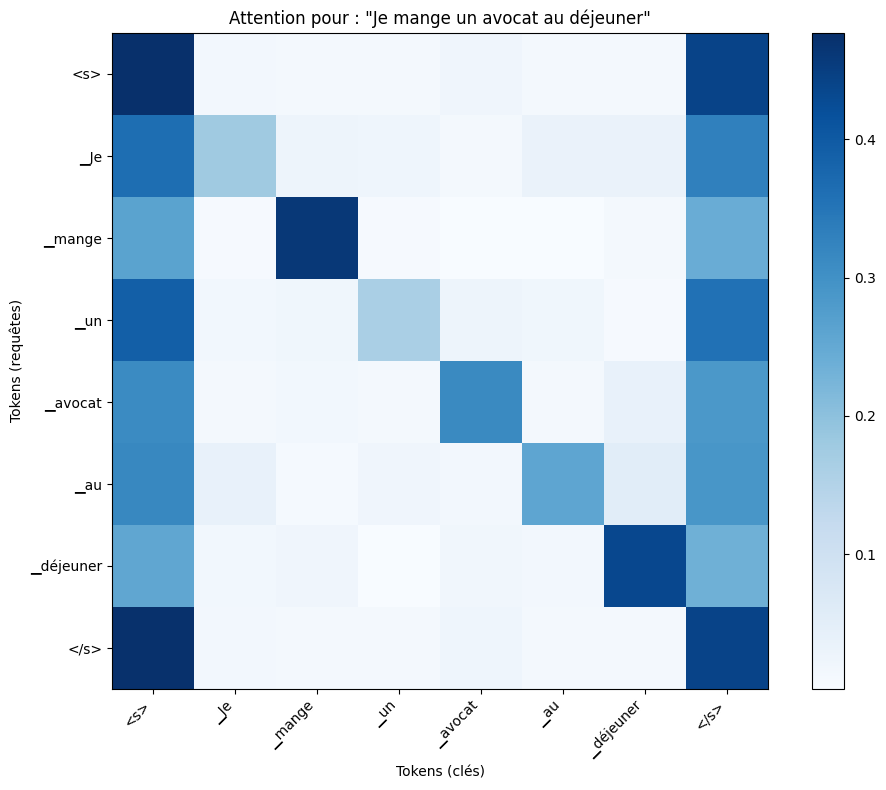


[i] Les cases foncées montrent où le modèle 'regarde'


In [30]:
import matplotlib.pyplot as plt

def visualize_attention(phrase):
    """
    Visualise les poids d'attention pour une phrase.
    """
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Prendre la dernière couche, première tête
    attention = outputs.attentions[-1][0, 0].numpy()

    # Visualiser
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attention, cmap='Blues')

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticklabels(tokens)

    ax.set_xlabel('Tokens (clés)')
    ax.set_ylabel('Tokens (requêtes)')
    ax.set_title(f'Attention pour : "{phrase}"')

    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig('attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()

    return attention, tokens

# Visualiser l'attention
attention, tokens = visualize_attention("Je mange un avocat au déjeuner")
print("\n[i] Les cases foncées montrent où le modèle 'regarde'")

##  Interpretation

La phrase analysée est : **"Je mange un avocat au déjeuner"**

Ce graphe est une **heatmap d'attention** : chaque case (i, j) représente
le poids d'attention que le token en **ligne** (requête) accorde au token
en **colonne** (clé). Plus la case est **foncée**, plus l'attention est élevée.

---

###  Ce que l'on observe

**1. La diagonale**  
Chaque token s'attend lui-même → comportement normal et attendu.  
Le modèle s'ancre d'abord sur sa propre position.

**2. Les tokens spéciaux `<s>` et `</s>`**  
Les cases foncées sur toute leur ligne et colonne montrent qu'ils
captent une attention forte sur l'ensemble de la séquence.  
→ Ils jouent le rôle de **résumé global** de la phrase.

**3. `_mange` (le verbe)**  
Il concentre une attention élevée sur lui-même.  
→ En tant que **pivot syntaxique**, il porte la structure de la phrase.

**4. `_déjeuner` (le complément)**  
Il reçoit de l'attention de plusieurs tokens voisins.  
→ Il ancre le **contexte temporel** de toute la phrase.

---

###  Pourquoi c'est important ?

> Un embedding statique (Word2Vec, Acte V) donnerait le **même vecteur**
> au mot *"avocat"* qu'il s'agisse d'un **fruit** 🥑 ou d'un **juriste** ⚖️.

Ici, grâce à l'attention, le modèle pondère les tokens *"mange"* et
*"déjeuner"* pour **désambiguïser** le sens du mot *"avocat"*.

C'est le principe fondamental des **représentations contextuelles**
introduites par les Transformers (Acte VI).

---

###  Résumé

| Observation | Interprétation |
|---|---|
| Diagonale foncée | Chaque token s'attend lui-même |
| `<s>` et `</s>` foncés | Capture du contexte global |
| `_mange` foncé | Verbe = pivot syntaxique |
| `_déjeuner` foncé | Ancrage du contexte de la phrase |

## 9. Récapitulatif

### Transformers vs Word Embeddings

| Aspect | Word Embeddings | Transformers |
|--------|-----------------|-------------|
| Vecteur | Fixe par mot | Contextuel |
| "avocat" | Même vecteur | Différent selon phrase |
| Négation | Mal gérée | Bien comprise |
| Taille | Petit (300 dim) | Grand (768+ dim) |

### BERT vs GPT

| | BERT | GPT |
|--|------|-----|
| Direction | Bidirectionnel | Gauche à droite |
| Usage | Comprendre | Générer |
| Exemples | Classification, Q&A | Chatbots, rédaction |

### Bibliothèques
- **Hugging Face Transformers** : pipeline facile à utiliser
- **CamemBERT** : BERT pour le français



# BON A SAVOIR

## 🌐 Sources gratuites et accessibles sur les tailles de paramètres

---

### Sites toujours gratuits

| Modèle | Source accessible | Lien |
|---|---|---|
| **BERT** | Page GitHub officielle Google | [github.com/google-research/bert](https://github.com/google-research/bert) |
| **CamemBERT** | Page Hugging Face du modèle | [huggingface.co/almanach/camembert-base](https://huggingface.co/almanach/camembert-base) |
| **GPT-2** | Annonce officielle OpenAI | [openai.com/index/better-language-models](https://openai.com/index/better-language-models/) |
| **GPT-4** | Technical Report OpenAI (PDF gratuit) | [arxiv.org/abs/2303.08774](https://arxiv.org/abs/2303.08774) |
| **LLaMA** | Paper Meta (PDF gratuit) | [arxiv.org/abs/2302.13971](https://arxiv.org/abs/2302.13971) |

---

### Astuce : Hugging Face comme source universelle

> Pour **n'importe quel modèle**, la page Hugging Face affiche
> directement le nombre de paramètres dans l'onglet **"Model card"**.
```
Exemples :
🔗 huggingface.co/google-bert/bert-base-uncased     → 110M params
🔗 huggingface.co/almanach/camembert-base           → 110M params  
🔗 huggingface.co/openai-community/gpt2             → 1.5B params
🔗 huggingface.co/meta-llama/Llama-2-7b             → 7B params
```

> Hugging Face est **la référence de facto** de la communauté NLP.  
> Toutes ces pages sont **gratuites, sans inscription**, et maintenues
> à jour par les équipes officielles des modèles.

---

### Pour aller plus loin : Wikipedia (FR)

> La page Wikipedia francophone de chaque modèle cite
> les paramètres avec sources :
```
🔗 fr.wikipedia.org/wiki/BERT_(modèle_de_langage)
🔗 fr.wikipedia.org/wiki/GPT-2
🔗 fr.wikipedia.org/wiki/LLaMA
```

> Idéal pour tes apprenants francophones !

---

### Rappel : arxiv.org est toujours gratuit

> Contrairement aux revues scientifiques classiques (Nature, IEEE...),  
> **arXiv est une archive ouverte** — tous les articles sont
> téléchargeables gratuitement en PDF, sans abonnement.

---

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur